# Objective 
- Identify/classify influential behavioral browsing trends towards purchase outcomes.

### Questions
- Does someone who purchases stay:
    - on the website longer?
    - switch pages more often?
    - stay on one page longer reading about a product?
    - browse towards more information based pages to learn about the product?

### Hypotheses
- They will stay on a website longer, even if they know what they are looking for.
- They will traverse through more pages as well if a number of products are similar and they want to read about them.
- The final page before purchasing they will stay on longer since what they read grabbed their attention over previous pages.
- An individual will browse towards information based pages to learn about organizational practices and quality assurance related factors.

---

# Imports

In [4]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Handling imbalance
from sklearn.utils import resample

# display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

---

# Load Data

In [5]:
raw_df = pd.read_csv("online_shoppers_intention.csv")

display(raw_df.head())
display(raw_df.shape)
display(raw_df.columns)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


(12330, 18)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### Data structure and feature types
- Dataset structure
  - 12,330 rows and 18 columns.
  - Mixture of continuous, count, binary, and coded categorical variables.
- Data quality
  - Check for missing values and duplicate rows.
- Feature types
  - `Month`, `VisitorType`, `Weekend` are categorical.
  - `SpecialDay`, `Browser`, `OperatingSystems`, `TrafficType`, and `Region` are numeric-coded categories
- Pre-processing decisions
  - Separate features into numeric vs categorical pipelines before modeling.

### We would like to look into 
1. Target Balance
2. Correlation heatmap
3. Behavioral differences with the target
4. Distribution shapes and zero inflation (transformations if needed)
5. Numerical variables distributions
6. Categorical variables 
7. Month based differences for seasonal trends (as well as special days)

> Source: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

---

# EDA:

## Target Variable Analysis

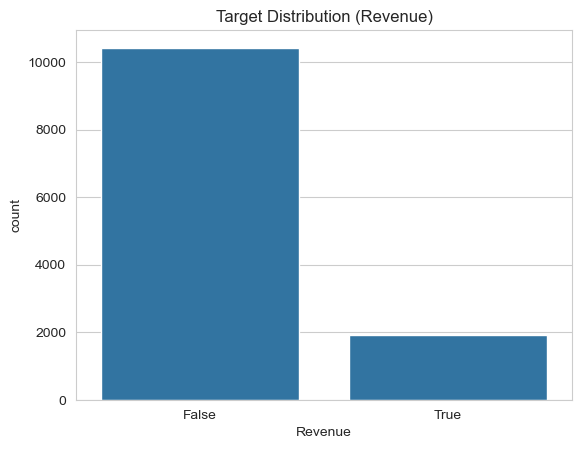

,Percentage,Count
Revenue,,
False,84.525547,10422
True,15.474453,1908


In [6]:
# Target Distribution
sns.countplot(x='Revenue', data=raw_df)
plt.title("Target Distribution (Revenue)")
plt.show()

# table
raw_target_distribution_table = pd.DataFrame({
    'Percentage': raw_df['Revenue'].value_counts(normalize=True) * 100,
    'Count': raw_df['Revenue'].value_counts()
})

raw_target_distribution_table

### Revenue Distribution:
- Class balance
    - 10,422 (84.5%) vs 1,908 (15.5%)
- Metric choice
    - Accuracy could mislead due to imbalance. Model predicting mostly "False" could appear 'good'.
    - Other metrics like F1, recall, PR AUC would suffice
##### Pre-processing decisions
- Stratified train/validate/test split to keep proportions similar across splits.

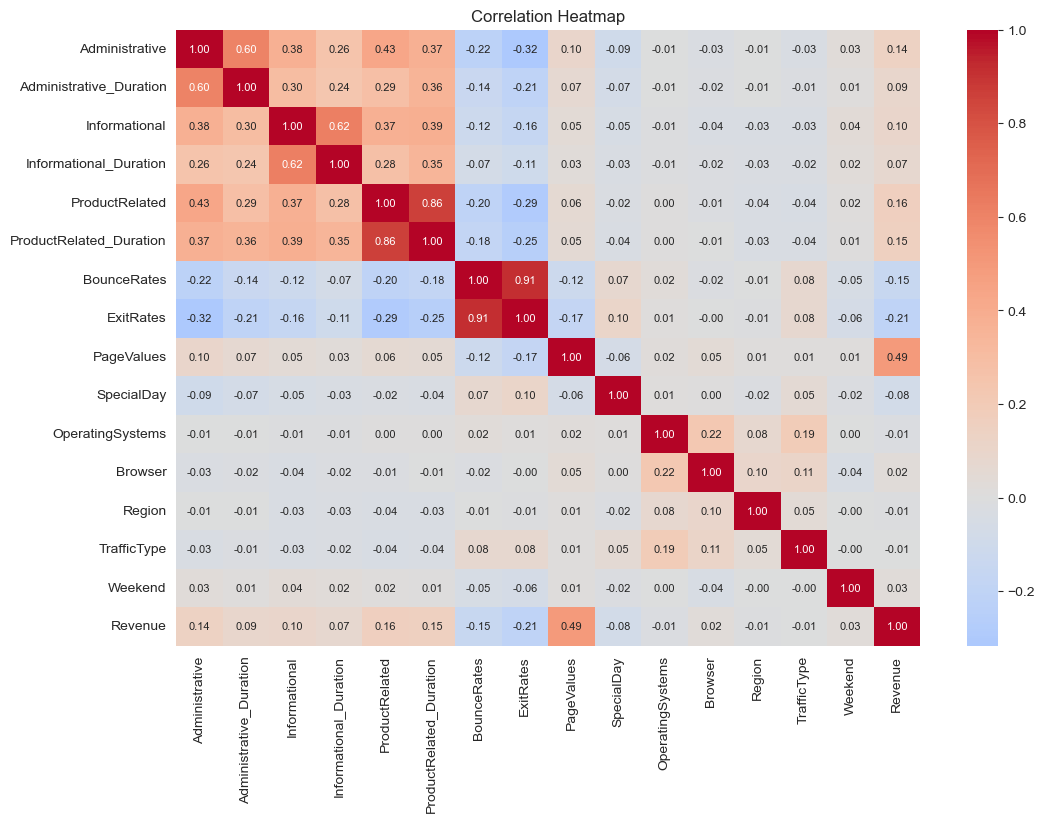

,Revenue
Revenue,1.000
PageValues,0.493
ProductRelated,0.159
ProductRelated_Duration,0.152
Administrative,0.139
Informational,0.095
Administrative_Duration,0.094
Informational_Duration,0.070
Weekend,0.029
Browser,0.024


In [7]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    raw_df.corr(numeric_only=True), 
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()

# correlation with target
raw_target_correlations_table = raw_df.corr(numeric_only=True)
pd.DataFrame(raw_target_correlations_table['Revenue']
             .sort_values(ascending=False)
             .round(3)
            )

### Correlation heatmap
- Strongest linear signal to `Revenue`
  - `PageValues` has the strongest positive linear relationship with `Revenue`.
  - `ExitRates` and `BounceRates` show the clearest negative relationships.

- Predictor overlap
  - Page-count and duration pairs are closely related.
  - `BounceRates` and `ExitRates` also appear to carry overlapping information.

##### Pre-processing decisions
- Watch for multicollinearity in linear models.
- For tree-based models, this overlap is less concerning.
- Coded numeric variables should still be treated as categorical rather than interpreted through correlation strength.

## NA/empty/zero Analysis

In [8]:
# Missing / zero summary table
n = len(raw_df)

# Create masks
na_mask = raw_df.isna()
empty_mask = raw_df.eq("")
zero_mask = raw_df.select_dtypes(include=np.number).eq(0)

# Create summary table
summary_table = pd.DataFrame(index=raw_df.columns)

summary_table["NA Count"] = na_mask.sum()
summary_table["NA %"] = na_mask.mean() * 100

summary_table["Empty String Count"] = empty_mask.sum()
summary_table["Empty String %"] = empty_mask.mean() * 100

summary_table["Zero Count"] = zero_mask.sum().reindex(raw_df.columns, fill_value=0)
summary_table["Zero %"] = (zero_mask.mean() * 100).reindex(raw_df.columns, fill_value=0)

# display 
display(summary_table.round(2))

,NA Count,NA %,Empty String Count,Empty String %,Zero Count,Zero %
Administrative,0,0.0,0,0.0,5768,46.78
Administrative_Duration,0,0.0,0,0.0,5903,47.88
Informational,0,0.0,0,0.0,9699,78.66
Informational_Duration,0,0.0,0,0.0,9925,80.49
ProductRelated,0,0.0,0,0.0,38,0.31
ProductRelated_Duration,0,0.0,0,0.0,755,6.12
BounceRates,0,0.0,0,0.0,5518,44.75
ExitRates,0,0.0,0,0.0,76,0.62
PageValues,0,0.0,0,0.0,9600,77.86
SpecialDay,0,0.0,0,0.0,11079,89.85


### Missingness
- NAs & empties
    - No features contain NAs or empty values, this was expected as noted from source, but checked anyway for best practice.

- Zero inflation
    - `Administrative`, `Administrative_Duration`, `Informational`, and `Informational_Duration` contain many zeros, suggesting that a large share of sessions did not involve those types of pages at all.
    - `PageValues` is also heavily zero-inflated, which is expected since many sessions likely did not progress far enough to generate purchase related data.
    - `SpecialDay` being nearly 90% zero is reasonable, since most browsing sessions would not occur near a holiday or special shopping-related date like black friday.
    - In contrast, `ProductRelated` and `ProductRelated_Duration` contain very few zeros, indicating that most sessions involved product-page interaction.

##### Take away
- The dataset does not deal with missingess, however we can see a trend with sparse behavior among most predictors

## Numeric Variable Analysis

In [9]:
# We don't want to look at numeric categorical features in EDA, they'll be preprocessed later
num_cat_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'] # numeric categorical features

num_cols = [
    col for col in raw_df.select_dtypes(include=np.number).columns
    if col not in num_cat_cols
]

In [10]:
# Skewness
raw_num_skewness = raw_df[num_cols].skew()

# raw skewness table
raw_num_skewness_table = pd.DataFrame(raw_num_skewness, columns=["Skewness"]).sort_values(by="Skewness", ascending=False)
raw_num_skewness_table

,Skewness
Informational_Duration,7.579185
ProductRelated_Duration,7.263228
PageValues,6.382964
Administrative_Duration,5.615719
ProductRelated,4.341516
Informational,4.036464
BounceRates,2.947855
ExitRates,2.148789
Administrative,1.960357


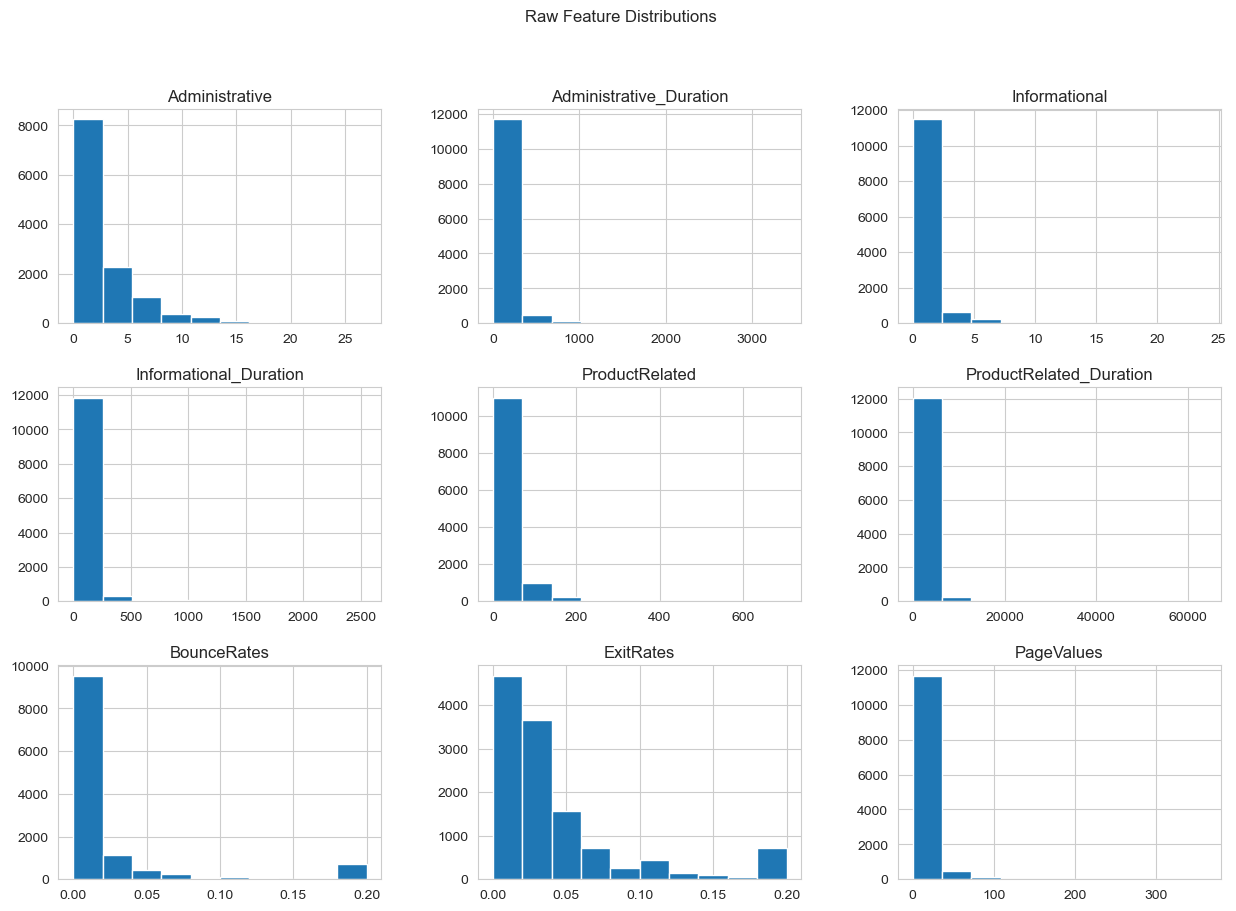

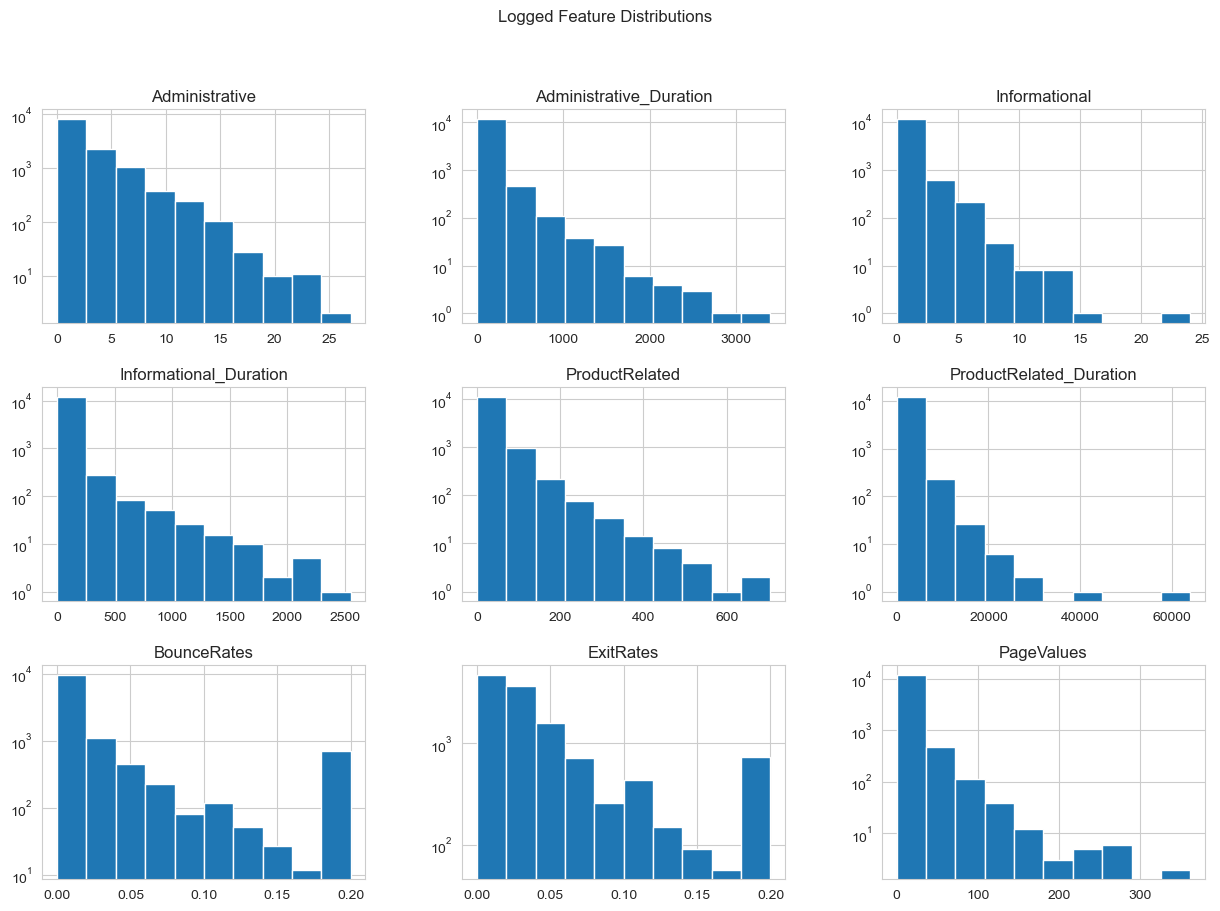

In [11]:
# Feature Distributions
raw_df[num_cols].hist(figsize=(15,10))
plt.suptitle("Raw Feature Distributions")
plt.show()

# logged distribution check
raw_df[num_cols].hist(figsize=(15,10), log=True)
plt.suptitle("Logged Feature Distributions")
plt.show()

### Raw vs log-transformed distributions:
- Raw vs transformed shape
  - The raw duration variables and `PageValues` are heavily compressed near 0 with long right tails.
  - After `log1p()`, the non-zero portion becomes much easier to inspect.

- Transformation insight
  - `ProductRelated_Duration` improves the most after transformation.
  - `Administrative_Duration`, `Informational_Duration`, and `PageValues` still retain a large spike at 0.

- Zero inflation
  - `SpecialDay`, `Informational`, `Informational_Duration`, and `PageValues` contain many zeros.

##### Pre-processing decisions:
- `log1p()` is a reasonable option for these variables, especially in linear models.
- Zeros should be kept as valid values.
- A separate binary indicator for any activity may be worth testing later for variables with many zeros.

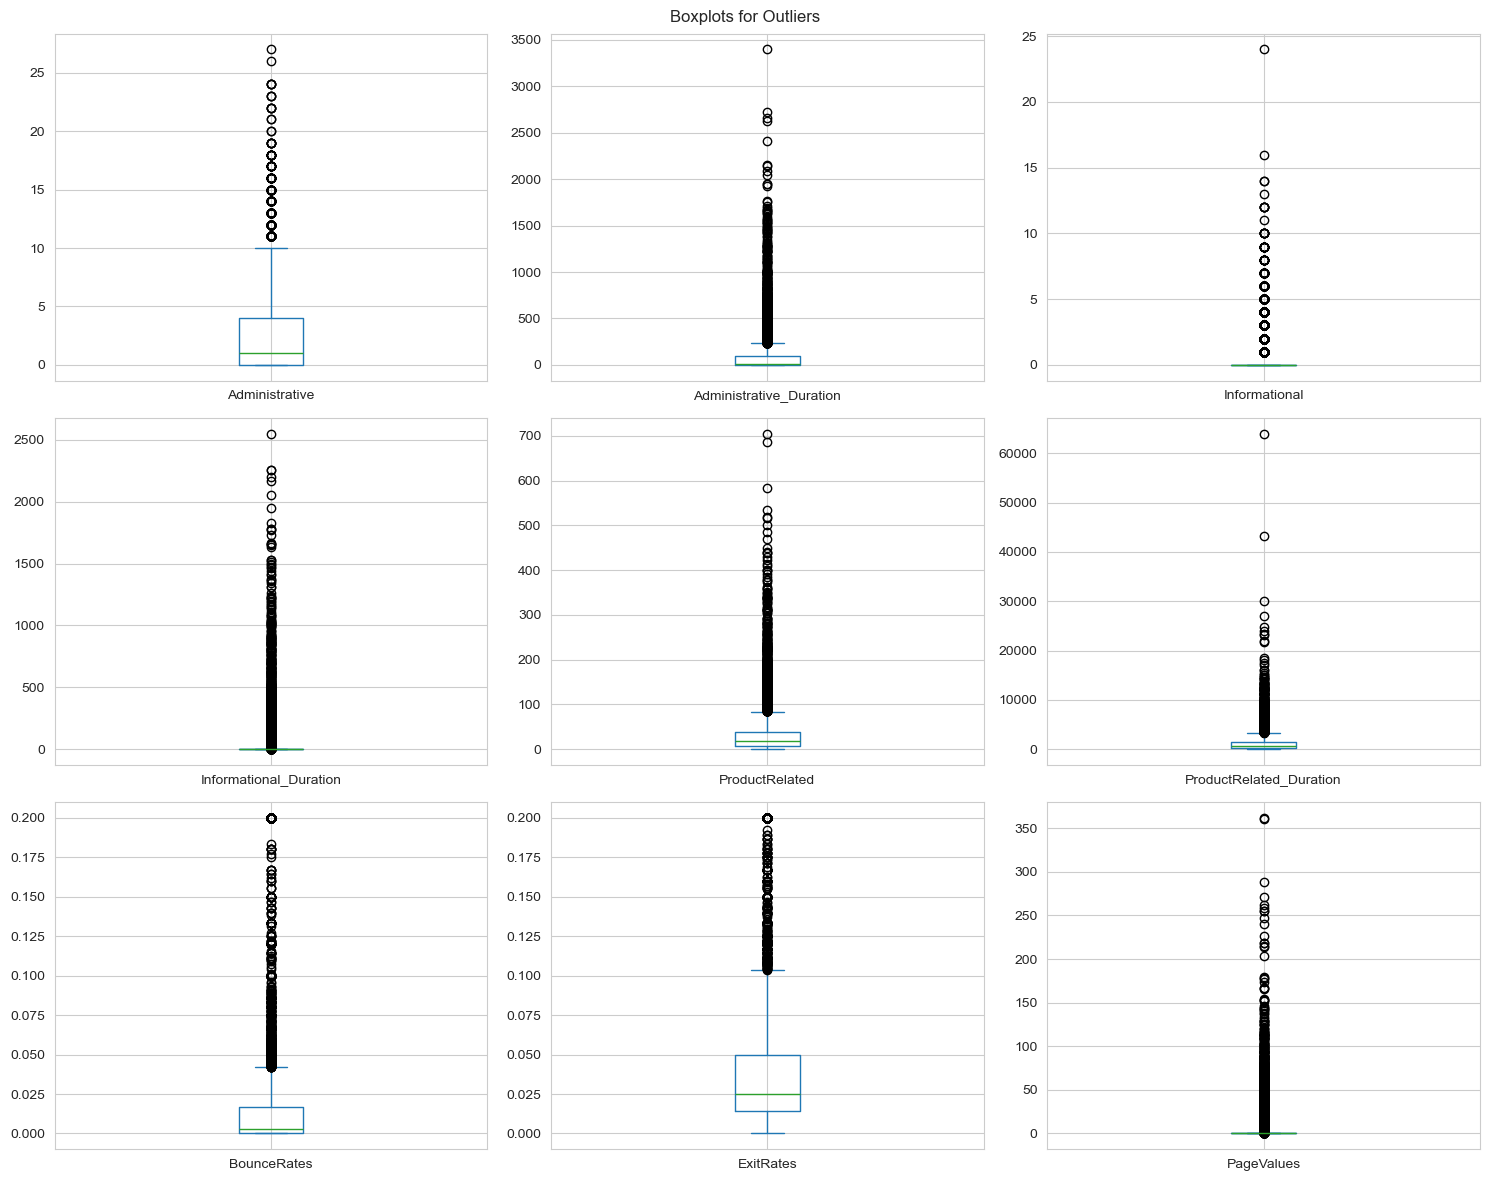

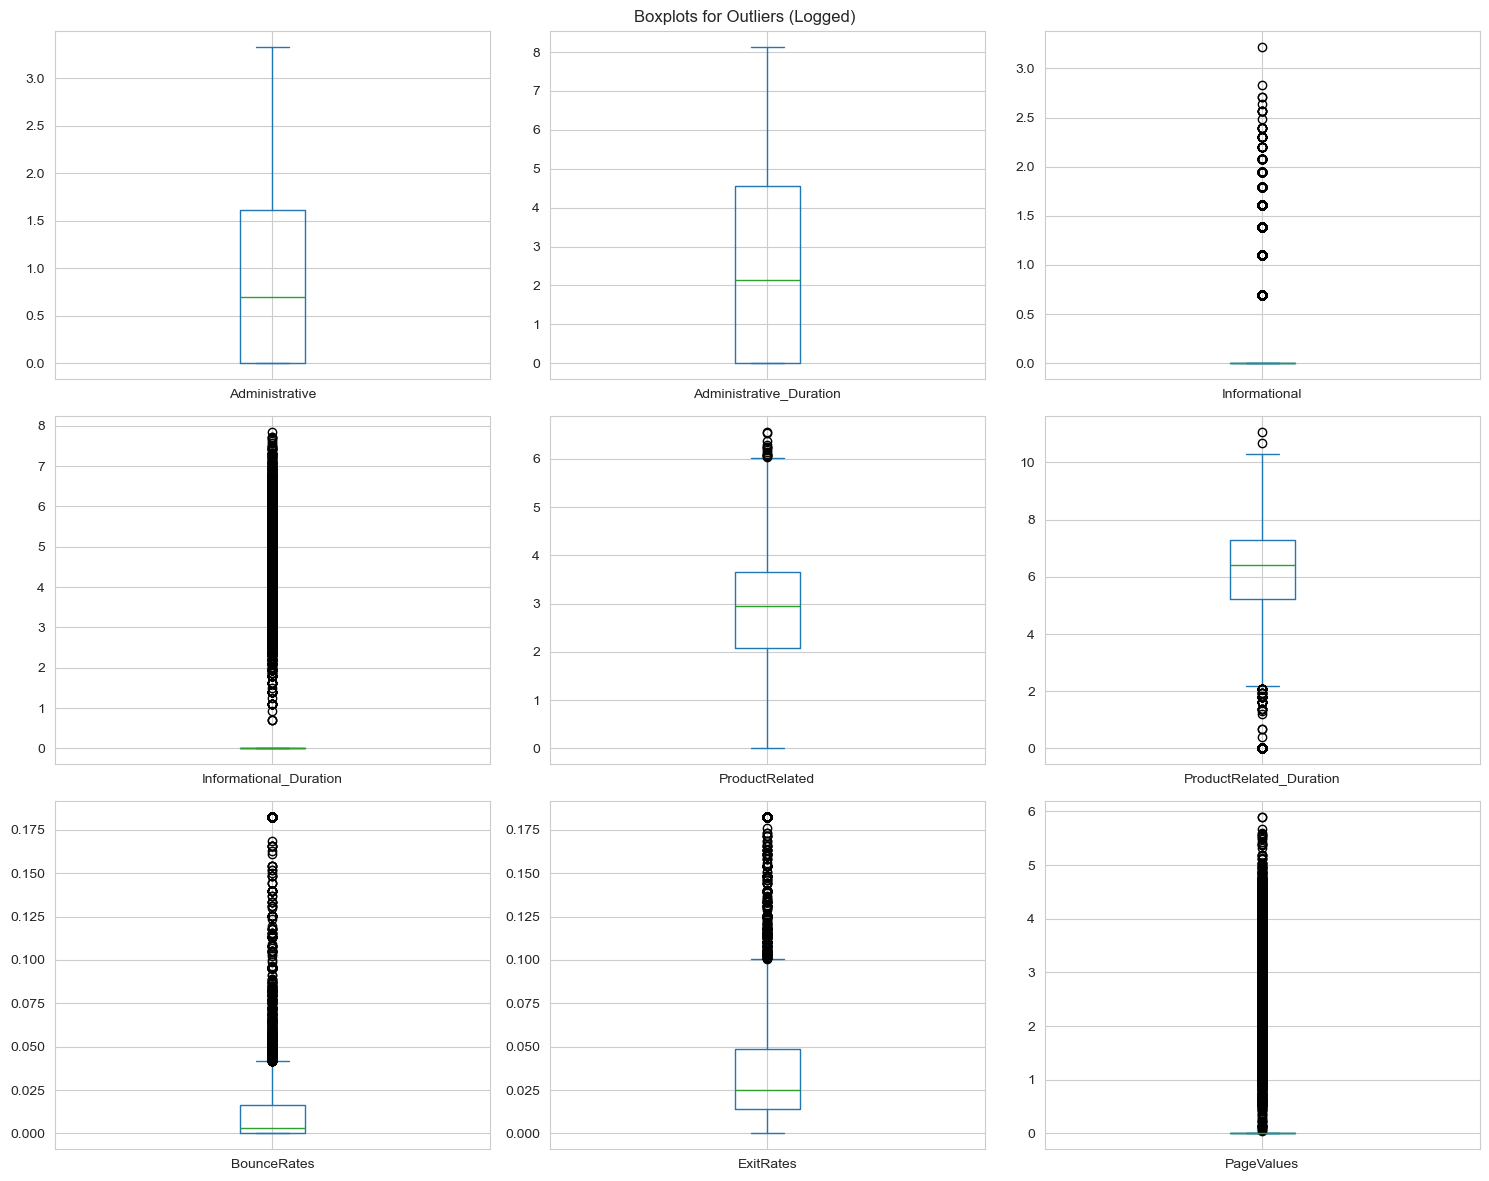

In [15]:
# Boxplots for outliers
raw_df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers")
plt.tight_layout()
plt.show()

# Boxplots for outliers (logged)
np.log1p(raw_df[num_cols]).plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers (Logged)")
plt.tight_layout()
plt.show()

### Outliers
- Heavily influenced due to being zero-inflated which compresses them near zero
- `Administrative` and `Administrative_Duration`, `ProductRelated` and `ProductRelated_Duration` becomes far less dominated which further encourages testing log and non-logged for our models.

## Categorical Variable Analysis

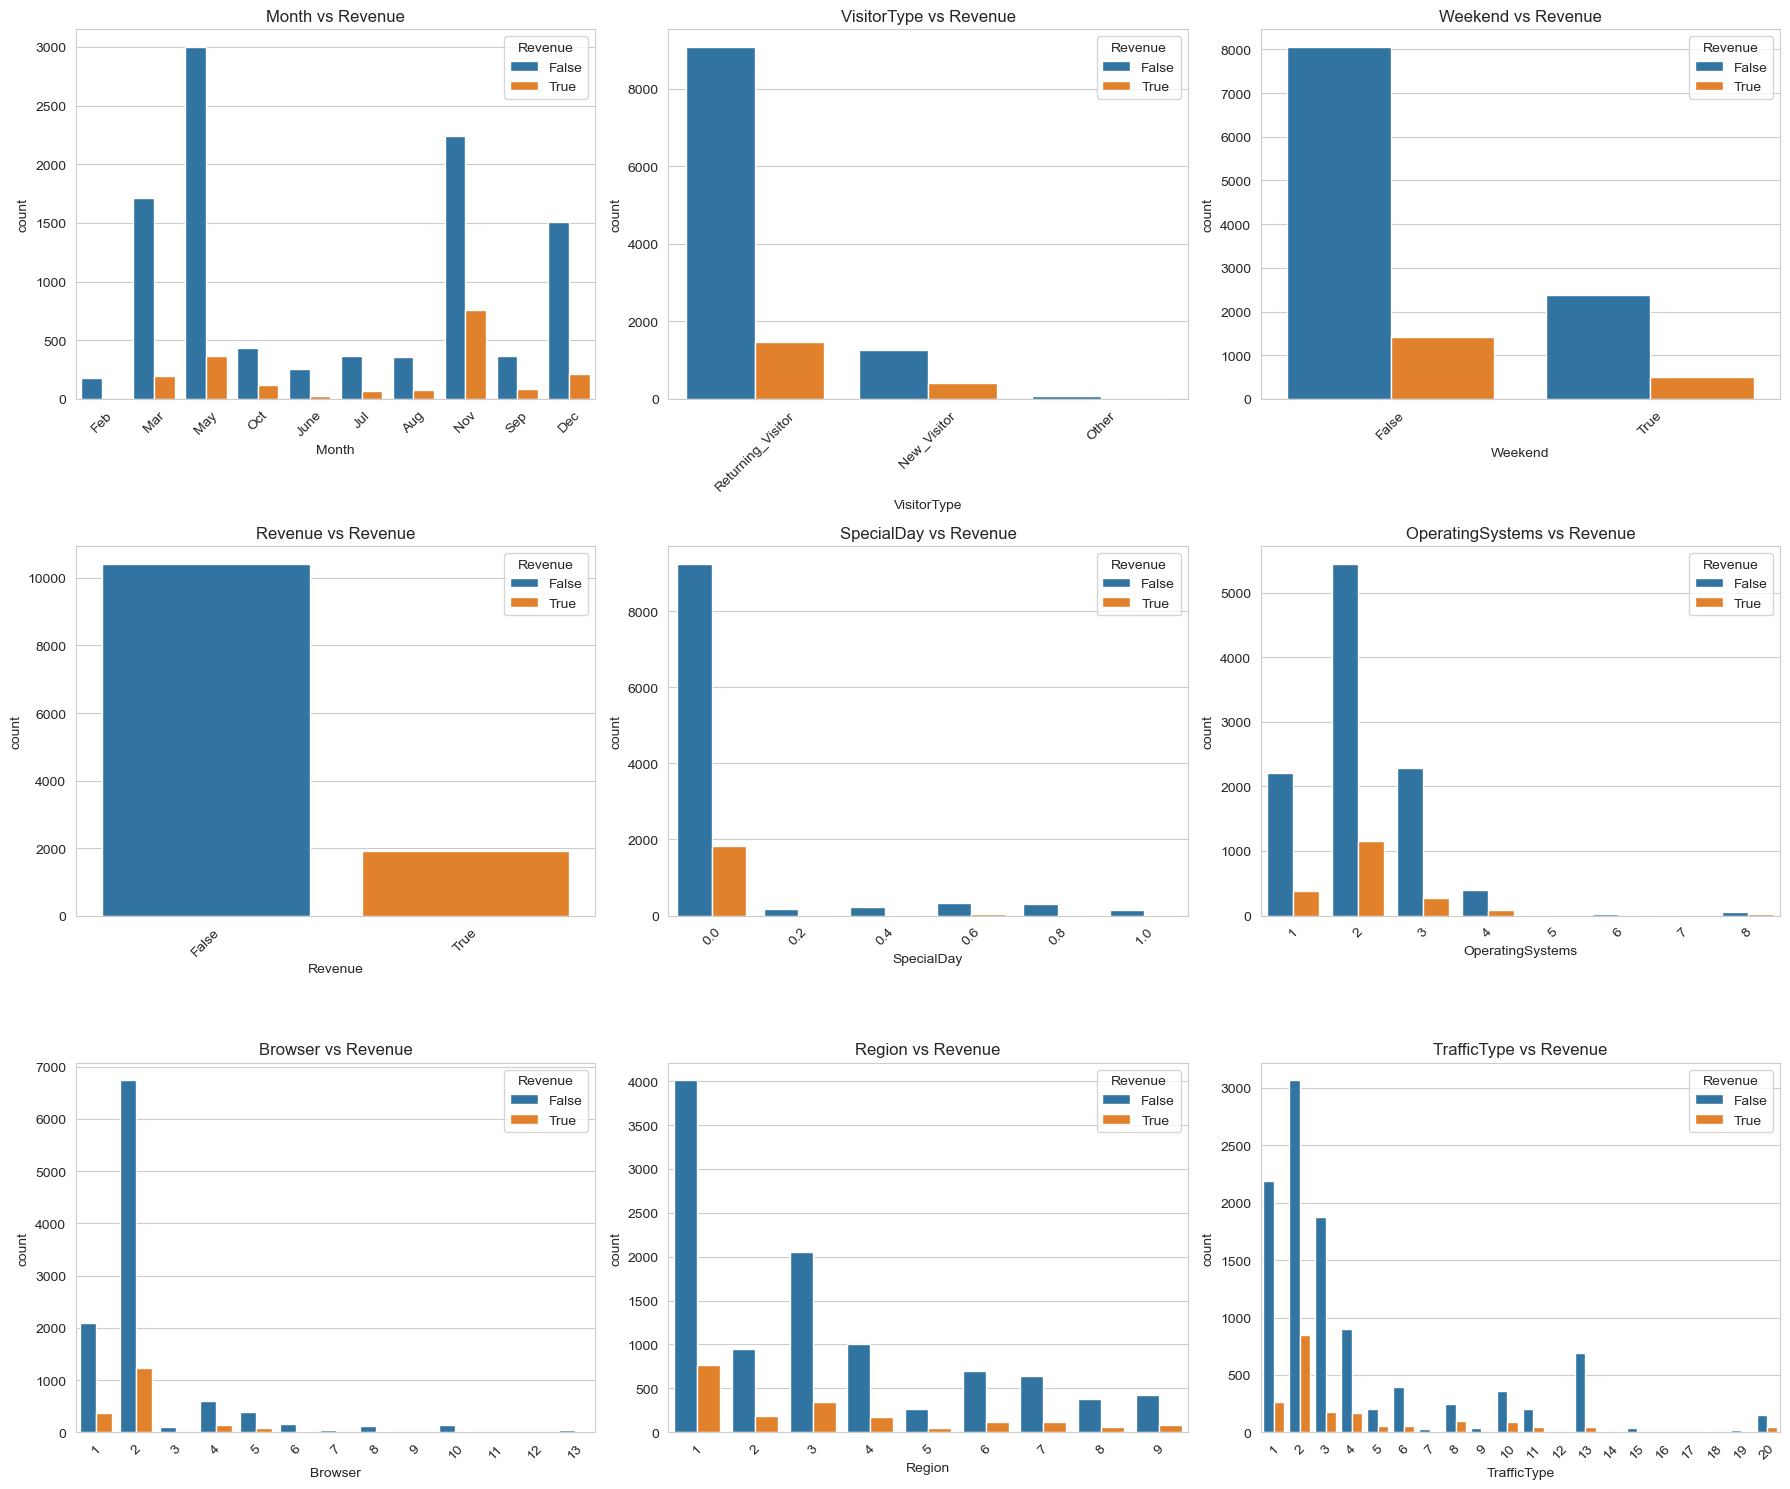


Month purchase rate:
Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64

VisitorType purchase rate:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Weekend purchase rate:
Weekend
True     0.173989
False    0.148911
Name: Revenue, dtype: float64

Revenue purchase rate:
Revenue
True     1.0
False    0.0
Name: Revenue, dtype: float64

SpecialDay purchase rate:
SpecialDay
0.0    0.165268
0.6    0.082621
0.2    0.078652
1.0    0.064935
0.4    0.053498
0.8    0.033846
Name: Revenue, dtype: float64

OperatingSystems purchase rate:
OperatingSystems
8    0.215190
4    0.177824
2    0.174973
5    0.166667
1    0.146615
7    0.142857
6    0.105263
3    0.104892
Name: Revenue, dtype: float64

Browser purchase rate:
Browser
12    0.300000
13    0.262295
10    0.

In [13]:
# Identify categorical columns
cat_cols = raw_df.select_dtypes(include=['object', 'bool']).columns.tolist() + num_cat_cols

# Set subplot grid shape
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Count plots for each categorical feature vs Revenue
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=raw_df, x=col, hue='Revenue', ax=ax)
    ax.set_title(f"{col} vs Revenue")
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplot axes
for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Purchase rate by category
for col in cat_cols:
    print(f"\n{col} purchase rate:")
    print(raw_df.groupby(col)['Revenue'].mean().sort_values(ascending=False))

### Categoricals
- Behavioral Trends
    - Seasonal trends aren't consistent enough to claim as true in this dataset. We can see a clear up tick in November we could attribute to black friday and holidays, like wise for December. However this is directly contradicted by March and May having such a strong influx.
    - Returning visitors take up a majority of the observations (this case individual shoppers), however as for ratio's, new visitors are commonly purchasing more.
    - Weekends have more traffic as well. 
- Numerical Encoded Predictors
    - `SpecialDay`; closer to 0 becomes a range of dates, closer to 1 becomes a centered point between that range from a given holiday. It is a closeness metric. Here we can see the behavior of people shopping near holidays, but not within the few days leading to or on said holiday.
    - `OperatingSystems` & `Browser` are not relevant user-behavior predictors without additional assumptions to an individuals character/profile.
    - Regions (`Region`) is unknown, but there are nine of them.
    - `TrafficType` is unknown, but there are 20 of them.
> None of these numerical predictors are properly documented for interpretation.

---

# Pre-processing

In [23]:
# Convert target to binary
raw_df['Revenue'] = raw_df['Revenue'].astype(int)
df = raw_df.copy()

# List of variables to drop for interpretability
drop_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# drop columns from df
df.drop(columns=drop_cols, inplace=True)

# Display the first few rows of the updated
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Month,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,Feb,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,Feb,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,Feb,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,Feb,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,Feb,Returning_Visitor,True,0


In [24]:
# Separate Features and Target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identify Feature Types
categorical_cols = ['Month', 'VisitorType', 'Weekend']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing Pipelines
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train/Validation/Test Split
# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split (validation + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8631, 12)
Validation: (1849, 12)
Test: (1850, 12)


---

# Modelling

In [25]:
# Baseline Model 1: Majority Class
majority_class = y_train.mode()[0]
y_pred_baseline = np.full_like(y_val, majority_class)

print("Baseline Accuracy:", accuracy_score(y_val, y_pred_baseline))
print("Baseline F1:", f1_score(y_val, y_pred_baseline))

Baseline Accuracy: 0.8453217955651704
Baseline F1: 0.0


In [26]:
# Baseline Model 2: Logistic Regression
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)
y_prob = log_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1563
           1       0.76      0.34      0.47       286

    accuracy                           0.88      1849
   macro avg       0.82      0.66      0.70      1849
weighted avg       0.87      0.88      0.86      1849

ROC-AUC: 0.8916307620722208


### Baseline models
- Majority Class
    - Accuracy is high due to imbalanced class, this just reinforces our EDA assumptions
    - F1 score is 0 since we never predicted a positive (the class we care about), due to the majority class being false (no purchases)

- Logistic Regression
    - F1 class 0: 0.93, model can identify non-purchase sessions
    - F1 class 1: 0.47, model is weaker at identifying purchase sessions
    - ROC-AUC: ~0.889 demonstrates this model can draw distinction between the two classes ; cutoff produces poor sensitivity for the minority class

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [27]:
# Decision Tree
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5))
])

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1563
           1       0.68      0.50      0.58       286

    accuracy                           0.89      1849
   macro avg       0.80      0.73      0.76      1849
weighted avg       0.88      0.89      0.88      1849



In [ ]:
# Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1563
           1       0.73      0.51      0.60       286

    accuracy                           0.90      1849
   macro avg       0.82      0.74      0.77      1849
weighted avg       0.89      0.90      0.89      1849

ROC-AUC: 0.9156074252043541


In [41]:
# Gradient Boosting
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_val)
y_prob = gb_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1563
           1       0.70      0.56      0.62       286

    accuracy                           0.90      1849
   macro avg       0.81      0.76      0.78      1849
weighted avg       0.89      0.90      0.89      1849

ROC-AUC: 0.920490897458268


In [42]:
# Suppport Vector Machine
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_val)
y_prob = svm_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1563
           1       0.72      0.49      0.58       286

    accuracy                           0.89      1849
   macro avg       0.81      0.73      0.76      1849
weighted avg       0.88      0.89      0.88      1849

ROC-AUC: 0.8557082712552961


In [43]:
# Cross Validation
scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.9316572312444906


In [44]:
# Final Evaluation on Test Set
final_model = rf_model  # choose best model

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1564
           1       0.75      0.58      0.66       286

    accuracy                           0.91      1850
   macro avg       0.84      0.77      0.80      1850
weighted avg       0.90      0.91      0.90      1850

Test ROC-AUC: 0.9303985656287447


---